ANÁLISE EXPLORATÓRIA DE DADOS - PROJETO 'HR - FREESQL'
_______________________________________________________________________________________________________________________

O objetivo dessa AED é verificar a relação entre salários, cargos/departamentos e localização geográfica dos funcionários de uma empresa. Os dados estão distribuídos em 7 planilhas obtidas no site Freesql. Inicialmente, extraímos os dados. Eles foram divididos em 2 planilhas: uma relacionada a funcionários, cargos e salários (Query1), e outra, a funcionarios e localização onde estão alocados (Query2). Com este projeto, pretendemos obter conclusões acerca de como os salários são distribuídos entre os funcionários em razão dos cargos e departamentos, e localidade onde prestam os serviços.


CARREGAMENTO DA BASE DE DADOS:
_______________________________________________________________________________________________________________________

In [1]:
# importando as bibliotecas necessárias para a análise e visualização de dados
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# importando a base de dados diretamente do GitHub - repositório "Projeto_avaliativo_final_M01"
URL_query1 = 'https://github.com/mariahbarros/Projeto_avaliativo_final_M01/blob/secundaria/Query1.csv?raw=true'
URL_query2 = 'https://github.com/mariahbarros/Projeto_avaliativo_final_M01/blob/secundaria/Query2.csv?raw=true'

# transformando as bases de dados em dataframes
df_query1 = pd.read_csv(URL_query1, sep=',', encoding='utf-8')
df_query2 = pd.read_csv(URL_query2, sep=',', encoding='utf-8')

# formatação para exibir os números em porcentagem com duas casas decimais
pd.set_option('display.float_format', '{:,.2f}%'.format)

# formatação para exibir os dataframes de forma mais legível
pd.set_option('display.width', None)          
pd.set_option('display.max_columns', None)    
pd.set_option('display.expand_frame_repr', False)  

# formatação geral dos gráficos
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)


QUERY1 : ANÁLISE PRIMÁRIA DOS DADOS
_______________________________________________________________________________________________________________________

In [2]:
# verificando as informações gerais sobre as bases de dados da Query1

# verificando o número de linhas e colunas do df_query1
print('=========== DIMENSÕES DA BASE DE DADOS ==========')
print(f'\nBase carregada com {df_query1.shape[0]} linhas e {len(df_query1.columns)} colunas.')                    

# verificando as primeiras e as últimas 5 linhas do dataframe
print('\n========== ANALISANDO AS PRIMEIRAS E ÚLTIMAS LINHAS DOS DADOS ==========')
print(f'\nInformações sobre as primeiras 5 linhas: \n{df_query1.head(5).to_string()}')                     
print(f'\nInformações sobre as últimas 5 linhas: \n{df_query1.tail(5).to_string()}')                       

# verificando as informações gerais sobre o dataframe
print('\n========== INFORMAÇÕES GERAIS ==========')
print(f'\nInformações gerais sobre os dados:')                                                      
print(df_query1.info())

# verificando a distribuição de valores únicos por coluna
print('\n========== INFORMAÇÕES SOBRE COLUNAS ==========')
print(f'\nVerificando a distribuição de valores únicos por coluna: \n{df_query1.nunique().to_string()}')   
 
# verificando a existência de valores duplicados no dataframe
print('\n========== INFORMAÇÕES SOBRE VALORES DUPLICADOS ==========')
print(f'\nVerificando duplicatas: {df_query1.duplicated().sum()}')                                         
 

=========== DIMENSÕES DA BASE DE DADOS ==========

Base carregada com 100 linhas e 15 colunas.

========== ANALISANDO AS PRIMEIRAS E ÚLTIMAS LINHAS DOS DADOS ==========

Informações sobre as primeiras 5 linhas: 
   EMPLOYEE_ID             HIRE_DATE  YEAR_HIRE_DATE  MONTH_HIRE_DATE  CONTRATATION_IN_MONTHS  START_DATE  END_DATE   JOB_TITLE DEPARTMENT_NAME  MANAGER_ID  SALARY  COMMISSION_PCT  MIN_SALARY  MAX_SALARY  LOCATION_ID
0          100  2013-06-17T00:00:00Z            2013                6                     156         NaN       NaN   President       Executive     100.00%   24000             NaN       20080       40000    1,700.00%
1          103  2016-01-03T00:00:00Z            2016                1                     126         NaN       NaN  Programmer              IT     103.00%    9000             NaN        4000       10000    1,400.00%
2          104  2017-05-21T00:00:00Z            2017                5                     109         NaN       NaN  Programmer          

QUERY1: TRATAMENTO DE DADOS
________________________________________________________________________________________________________________________________________________

In [3]:
# 1) transformando a coluna HIRE_DATE em formato datetime

# ajustes antes da conversão
df_query1['HIRE_DATE'] = df_query1['HIRE_DATE'].astype(str).str.strip()

# conversão
df_query1['HIRE_DATE'] = pd.to_datetime(df_query1['HIRE_DATE'], format='ISO8601', errors='coerce')

# verificando o período analisado no dataframe
print("\n=====Verificando a transfomação:=====\n")
print(df_query1['HIRE_DATE'].info())


=====Verificando a transfomação:=====

<class 'pandas.Series'>
RangeIndex: 100 entries, 0 to 99
Series name: HIRE_DATE
Non-Null Count  Dtype              
--------------  -----              
100 non-null    datetime64[us, UTC]
dtypes: datetime64[us, UTC](1)
memory usage: 932.0 bytes
None


In [4]:
# 2) transformando a coluna MANAGER_ID em texto (str) para ajuste de configuração

df_query1['MANAGER_ID'] = (df_query1['MANAGER_ID'].astype('Int64').astype('string'))

# verificando o tipo após a conversão
print("\n=====Verificando o tipo após a conversão:=====\n")
print(df_query1['MANAGER_ID'].dtypes)


=====Verificando o tipo após a conversão:=====

string


In [5]:
# 3) excluindo as colunas START_DATE e END_DATE do dataframe df_query1, pois todos os dados são nulos

df_query1 = df_query1.drop(columns=['START_DATE', 'END_DATE'])

# excluindo a coluna LOCATION_ID do dataframe df_query1, pois não será utilizada na análise
df_query1 = df_query1.drop(columns=['LOCATION_ID'])

# verificando a exclusão das colunas
print("\n=====Verificando a exclusão das colunas:=====\n")
print(df_query1.columns.tolist())


=====Verificando a exclusão das colunas:=====

['EMPLOYEE_ID', 'HIRE_DATE', 'YEAR_HIRE_DATE', 'MONTH_HIRE_DATE', 'CONTRATATION_IN_MONTHS', 'JOB_TITLE', 'DEPARTMENT_NAME', 'MANAGER_ID', 'SALARY', 'COMMISSION_PCT', 'MIN_SALARY', 'MAX_SALARY']


In [6]:
# 4) tratando as nulidades

# confirmando a quantidade de valores nulos
df_query1.info()

# verificando a forma como os valores não nulos estão distribuídos na coluna 'COMMISSION_PCT'
print("\n=====Valores nulos na coluna 'COMMISSION_PCT':=====\n")
print(df_query1[df_query1['COMMISSION_PCT'].notna()]['COMMISSION_PCT'].head())

# verificando os cargos que recebem comissão
cargos_com_comissao = df_query1[df_query1['COMMISSION_PCT'] > 0]['JOB_TITLE'].unique()

print(print("\n=====Cargos que recebem comissão:=====\n"))
print(cargos_com_comissao)

# definindo valores para substituir nulos
resolucao_nulidades = {
    'DEPARTMENT_NAME': 'Sales',
    'MANAGER_ID': 'dado_ausente',
    'LOCATION_ID': 'dado_ausente',
    'COMMISSION_PCT': 0.0  
}

# efetivando as substituições
df_query1.fillna(value=resolucao_nulidades, inplace=True)

print(print("\n=====Verificação do tratamento das nulidades:=====\n"))
print(df_query1.isna().sum())

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype              
---  ------                  --------------  -----              
 0   EMPLOYEE_ID             100 non-null    int64              
 1   HIRE_DATE               100 non-null    datetime64[us, UTC]
 2   YEAR_HIRE_DATE          100 non-null    int64              
 3   MONTH_HIRE_DATE         100 non-null    int64              
 4   CONTRATATION_IN_MONTHS  100 non-null    int64              
 5   JOB_TITLE               100 non-null    str                
 6   DEPARTMENT_NAME         99 non-null     str                
 7   MANAGER_ID              99 non-null     string             
 8   SALARY                  100 non-null    int64              
 9   COMMISSION_PCT          34 non-null     float64            
 10  MIN_SALARY              100 non-null    int64              
 11  MAX_SALARY              100 non-null    int64            

In [7]:
# 5) renomeando as colunas do dataframe df_query1

# dicionário de tradução
renomear_colunas = {
    'EMPLOYEE_ID': 'EMPREGADO_ID',
    'HIRE_DATE': 'DATA_ADMISSAO',
    'YEAR_HIRE_DATE': 'ANO_ADMISSAO',
    'MONTH_HIRE_DATE': 'MES_ADMISSAO',
    'CONTRATATION_IN_MONTHS': 'TEMPO_CONTRATACAO_MESES',
    'JOB_TITLE': 'CARGO',
    'DEPARTMENT_NAME': 'DEPARTAMENTO',
    'MANAGER_ID': 'GERENTE_ID',
    'SALARY': 'SALARIO',
    'COMMISSION_PCT': 'COMISSAO_PCT',
    'MIN_SALARY': 'MIN_SALARIO',
    'MAX_SALARY': 'MAX_SALARIO',
    
}

df_query1 = df_query1.rename(columns=renomear_colunas)

# verificando a renomeação
print("\n=====NOME COLUNAS QUERY01:=====\n")
print(df_query1.columns.tolist())


=====NOME COLUNAS QUERY01:=====

['EMPREGADO_ID', 'DATA_ADMISSAO', 'ANO_ADMISSAO', 'MES_ADMISSAO', 'TEMPO_CONTRATACAO_MESES', 'CARGO', 'DEPARTAMENTO', 'GERENTE_ID', 'SALARIO', 'COMISSAO_PCT', 'MIN_SALARIO', 'MAX_SALARIO']


In [8]:
# 6) visualizando os valores em CARGO para renomeação

print("\n=====Valores em CARGO:=====\n")
print(df_query1['CARGO'].unique())

# renomeando os valores em CARGO
renomear_cargos = {
    'President': 'presidente',
    'Programmer': 'programador',
    'Finance Manager': 'gerente_financeiro',
    'Accountant': 'contador',
    'Purchasing Clerk': 'assistente_compras',
    'Stock Manager': 'gerente_estoque',
    'Stock Clerk': 'assistente_estoque',
    'Sales Manager': 'gerente_vendas',
    'Sales Representative': 'representante_vendas',
    'Shipping Clerk': 'assistente_expedicao',
    'Marketing Representative': 'representante_MKT',
    'Human Resources Representative': 'representante_RH',
    'Public Relations Representative': 'representante_RP',
    'Accounting Manager': 'gerente_contabilidade',
    'Public Accountant': 'contador_publico'
}

df_query1['CARGO'] = df_query1['CARGO'].replace(renomear_cargos)

# verificando a renomeação:
print("\n=====NOME COLUNAS QUERY01:=====\n")
print(df_query1['CARGO'].unique())


=====Valores em CARGO:=====

<StringArray>
[                      'President',                      'Programmer',
                 'Finance Manager',                      'Accountant',
                'Purchasing Clerk',                   'Stock Manager',
                     'Stock Clerk',                   'Sales Manager',
            'Sales Representative',                  'Shipping Clerk',
        'Marketing Representative',  'Human Resources Representative',
 'Public Relations Representative',              'Accounting Manager',
               'Public Accountant']
Length: 15, dtype: str

=====NOME COLUNAS QUERY01:=====

<StringArray>
[           'presidente',           'programador',    'gerente_financeiro',
              'contador',    'assistente_compras',       'gerente_estoque',
    'assistente_estoque',        'gerente_vendas',  'representante_vendas',
  'assistente_expedicao',     'representante_MKT',      'representante_RH',
      'representante_RP', 'gerente_contabilidade

In [9]:
# 7) visualizando os valores em DEPARTAMENTO para renomeação

print("\n=====Valores em DEPARTAMENTO:=====\n")
print(df_query1['DEPARTAMENTO'].unique())

# renomeando os valores em DEPARTAMENTO
renomear_departamentos = {
    'Executive': 'diretoria',
    'IT': 'TI',
    'Finance': 'financeiro',
    'Purchasing': 'compras',
    'Shipping': 'expedicao',
    'Sales': 'vendas',
    'Marketing': 'MKT',
    'Human Resources': 'RH',
    'Public Relations': 'RP',
    'Accounting': 'contabilidade',
    
}

df_query1['DEPARTAMENTO'] = df_query1['DEPARTAMENTO'].replace(renomear_departamentos)

# verificando a renomeação
print("\n=====NOME COLUNAS QUERY01:=====\n")
print(df_query1['DEPARTAMENTO'].unique())


=====Valores em DEPARTAMENTO:=====

<StringArray>
[       'Executive',               'IT',          'Finance',
       'Purchasing',         'Shipping',            'Sales',
        'Marketing',  'Human Resources', 'Public Relations',
       'Accounting']
Length: 10, dtype: str

=====NOME COLUNAS QUERY01:=====

<StringArray>
[    'diretoria',            'TI',    'financeiro',       'compras',
     'expedicao',        'vendas',           'MKT',            'RH',
            'RP', 'contabilidade']
Length: 10, dtype: str


In [10]:
# 8) estatística descritiva das colunas TEMPO_CONTRATACAO_MESES', SALARIO', 'COMISSAO_PCT', 'MIN_SALARIO' e 'MAX_SALARIO' no dataframe df_query1

colunas_estatisticas = [
    'TEMPO_CONTRATACAO_MESES',
    'SALARIO',
    'COMISSAO_PCT',
    'MIN_SALARIO',
    'MAX_SALARIO'
]

# exibindo as estatísticas descritivas
print("\n===== Estatísticas descritivas das variáveis numéricas: =====\n")
print(df_query1[colunas_estatisticas].describe().map('{:.2f}'.format))

print("\n===== Coeficientes de variação: =====\n")
for col in colunas_estatisticas:
    cv = df_query1[col].std() / df_query1[col].mean() * 100
    print(f"{col}: {cv:.2f}%")



===== Estatísticas descritivas das variáveis numéricas: =====

      TEMPO_CONTRATACAO_MESES   SALARIO COMISSAO_PCT MIN_SALARIO MAX_SALARIO
count                  100.00    100.00       100.00      100.00      100.00
mean                   125.88   6125.16         0.08     4428.40     9246.32
std                     18.40   3641.12         0.12     2690.42     5088.77
min                     98.00   2100.00         0.00     2008.00     5000.00
25%                    111.00   3000.00         0.00     2500.00     5500.00
50%                    125.00   6000.00         0.00     4000.00     9000.00
75%                    136.00   8325.00         0.15     6000.00    12008.00
max                    169.00  24000.00         0.40    20080.00    40000.00

===== Coeficientes de variação: =====

TEMPO_CONTRATACAO_MESES: 14.62%
SALARIO: 59.45%
COMISSAO_PCT: 154.64%
MIN_SALARIO: 60.75%
MAX_SALARIO: 55.04%


In [11]:
# 9) estatística descritiva para os salários por departamento, considerando apenas os departamentos com mais de 1 funcionário

# verificando quantos funcionários existem por departamento
contagem_departamento = df_query1['DEPARTAMENTO'].value_counts()

# filtrando só os departamentos com mais de 1 funcionário
departamentos_validos = contagem_departamento[contagem_departamento > 1].index

df_filtrado = df_query1[df_query1['DEPARTAMENTO'].isin(departamentos_validos)]

tabela_describe = df_filtrado.groupby('DEPARTAMENTO')['SALARIO'].describe().map('{:.2f}'.format)
#invertendo a tabela para melhor visualização
tabela_describe_transposta = tabela_describe.T    

print("\n===== Estatísticas descritivas de salários por departamento: =====\n")
print(tabela_describe_transposta)



===== Estatísticas descritivas de salários por departamento: =====

DEPARTAMENTO       TI  compras contabilidade expedicao financeiro    vendas
count            5.00     5.00          2.00     44.00       6.00     34.00
mean          5760.00  2780.00      10154.00   3375.00    8601.33   8908.82
std           1925.62   238.75       2621.95   1341.66    1804.13   2060.50
min           4200.00  2500.00       8300.00   2100.00    6900.00   6100.00
25%           4800.00  2600.00       9227.00   2600.00    7725.00   7225.00
50%           4800.00  2800.00      10154.00   3050.00    8000.00   8900.00
75%           6000.00  2900.00      11081.00   3525.00    8800.00  10000.00
max           9000.00  3100.00      12008.00   8200.00   12008.00  14000.00


QUERY2 : ANÁLISE PRIMÁRIA DOS DADOS
________________________________________________________________________________________________________________________________________________

In [12]:
# 10) verificando as informações gerais sobre as bases de dados da Query2

# verificando o número de linhas e colunas do df_query2
print('========== DIMENSÕES DA BASE DE DADOS ==========')
print(f'\nBase carregada com {df_query2.shape[0]} linhas e {len(df_query2.columns)} colunas.')                    

# verificando as primeiras e as últimas 5 linhas do dataframe
print('\n========== ANALISANDO AS PRIMEIRAS E ÚLTIMAS LINHAS DOS DADOS ==========')
print(f'\nInformações sobre as primeiras 5 linhas: \n{df_query2.head(5).to_string()}')                     
print(f'\nInformações sobre as últimas 5 linhas: \n{df_query2.tail(5).to_string()}')                       

# verificando as informações gerais sobre o dataframe
print('\n========== INFORMAÇÕES GERAIS ==========')
print(f'\nInformações gerais sobre os dados:')                                                      
print(df_query2.info())

# verificando a distribuição de valores únicos por coluna
print('\n========== INFORMAÇÕES SOBRE COLUNAS ==========')
print(f'\nVerificando a distribuição de valores únicos por coluna: \n{df_query2.nunique().to_string()}')   
 
# verificando a existência de valores duplicados no dataframe
print('\n========== INFORMAÇÕES SOBRE VALORES DUPLICADOS ==========')
print(f'\nVerificando duplicatas: {df_query2.duplicated().sum()}')

========== DIMENSÕES DA BASE DE DADOS ==========

Base carregada com 100 linhas e 10 colunas.

========== ANALISANDO AS PRIMEIRAS E ÚLTIMAS LINHAS DOS DADOS ==========

Informações sobre as primeiras 5 linhas: 
   EMPLOYEE_ID  SALARY  COMMISSION_PCT  END_DATE       STREET_ADDRESS POSTAL_CODE       CITY STATE_PROVINCE              COUNTRY_NAME REGION_NAME
0          100   24000             NaN       NaN      2004 Charade Rd       98199    Seattle     Washington  United States of America    Americas
1          103    9000             NaN       NaN  2014 Jabberwocky Rd       26192  Southlake          Texas  United States of America    Americas
2          104    6000             NaN       NaN  2014 Jabberwocky Rd       26192  Southlake          Texas  United States of America    Americas
3          105    4800             NaN       NaN  2014 Jabberwocky Rd       26192  Southlake          Texas  United States of America    Americas
4          106    4800             NaN       NaN  2014 Jabb

QUERY2: TRATAMENTO DE DADOS
________________________________________________________________________________________________________________________________________________

In [13]:
# 11) excluindo a coluna END_DATE do dataframe df_query2, pois todos os dados são nulos

df_query2 = df_query2.drop(columns=['END_DATE'])

# verificando a exclusão
print("\nVerificando a exclusão da coluna:")
print(df_query2.columns)


Verificando a exclusão da coluna:
Index(['EMPLOYEE_ID', 'SALARY', 'COMMISSION_PCT', 'STREET_ADDRESS',
       'POSTAL_CODE', 'CITY', 'STATE_PROVINCE', 'COUNTRY_NAME', 'REGION_NAME'],
      dtype='str')


In [14]:
# 12) tratando as nulidades

# confirmando a quantidade de valores nulos
print(df_query2.info())

# definindo valores para substituir nulos
resolucao_nulidades = {
    'STREET_ADDRESS': 'dado_ausente',
    'POSTAL_CODE': 'dado_ausente',
    'CITY': 'dado_ausente',
    'STATE_PROVINCE': 'dado_ausente',
    'COUNTRY_NAME': 'dado_ausente',
    'REGION_NAME': 'dado_ausente',
    'COMMISSION_PCT': 0.0  
}

# efetivando as substituições
df_query2.fillna(value=resolucao_nulidades, inplace=True)

print("\n==================================================\n")

print("\nVerificação:\n")
print(df_query2.isna().sum())

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   EMPLOYEE_ID     100 non-null    int64  
 1   SALARY          100 non-null    int64  
 2   COMMISSION_PCT  34 non-null     float64
 3   STREET_ADDRESS  99 non-null     str    
 4   POSTAL_CODE     98 non-null     str    
 5   CITY            99 non-null     str    
 6   STATE_PROVINCE  98 non-null     str    
 7   COUNTRY_NAME    99 non-null     str    
 8   REGION_NAME     99 non-null     str    
dtypes: float64(1), int64(2), str(6)
memory usage: 7.2 KB
None



Verificação:

EMPLOYEE_ID       0
SALARY            0
COMMISSION_PCT    0
STREET_ADDRESS    0
POSTAL_CODE       0
CITY              0
STATE_PROVINCE    0
COUNTRY_NAME      0
REGION_NAME       0
dtype: int64


In [15]:
# 13) renomeando as colunas do dataframe df_query2

# dicionário de tradução:
renomear_colunas = {
    'EMPLOYEE_ID': 'EMPREGADO_ID',
    'SALARY': 'SALARIO',
    'COMMISSION_PCT': 'COMISSAO_PCT',
    'STREET_ADDRESS': 'ENDERECO',
    'POSTAL_CODE': 'CEP',
    'CITY': 'CIDADE',
    'STATE_PROVINCE': 'ESTADO',
    'COUNTRY_NAME': 'PAIS',
    'REGION_NAME': 'REGIAO',
        
}

df_query2 = df_query2.rename(columns=renomear_colunas)

# verificando a renomeação
print("\n=====NOME COLUNAS QUERY02:=====\n")
print(df_query2.columns.tolist())


=====NOME COLUNAS QUERY02:=====

['EMPREGADO_ID', 'SALARIO', 'COMISSAO_PCT', 'ENDERECO', 'CEP', 'CIDADE', 'ESTADO', 'PAIS', 'REGIAO']


ANÁLISE EXPLORATÓRIA DE DADOS - QUERY1 E QUERY2:
________________________________________________________________________________________________________________________________________________

In [16]:
# 14) verificando os dados das colunas 'CARGO' e 'DEPARTAMENTO' (Query1), e 'ENDERECO', 'CEP', 'CIDADE', 'ESTADO', 'PAIS' e 'REGIAO' (Query2)

# Query1
print("\n===== Verificando cargos e departamentos: =====\n")
print(df_query1[['CARGO','DEPARTAMENTO']].value_counts())

print("\n====================================================\n")

# Query2
colunas_analise = [
    'ENDERECO', 
    'CEP', 
    'CIDADE', 
    'ESTADO', 
    'PAIS', 
    'REGIAO'
]
 
print("\n===== Verificando localizações: =====\n")
print(df_query2[colunas_analise].value_counts())

print("\n====================================================\n")

# unindo as duas queries para obter informações sobre os funcionários, cargos, departamentos e localizações
df_unido = df_query1.merge(
    df_query2[['EMPREGADO_ID', 'CIDADE', 'ESTADO', 'PAIS', 'REGIAO']], on='EMPREGADO_ID', how='left')

df_unido_valido = df_unido[df_unido['CIDADE'] != 'dado_ausente']

tabela_cargo_dept_cidade = df_unido_valido.groupby(['CARGO', 'DEPARTAMENTO', 'CIDADE', 'ESTADO', 'PAIS', 'REGIAO']).size().reset_index(name='QTD_FUNCIONARIOS')
tabela_cargo_dept_cidade = tabela_cargo_dept_cidade.sort_values(['CARGO', 'QTD_FUNCIONARIOS'], ascending=[True, False])

print("\n===== Verificando cargos, departamentos e localizações: =====\n")
print(tabela_cargo_dept_cidade)


===== Verificando cargos e departamentos: =====

CARGO                  DEPARTAMENTO 
representante_vendas   vendas           29
assistente_estoque     expedicao        20
assistente_expedicao   expedicao        20
programador            TI                5
contador               financeiro        5
assistente_compras     compras           5
gerente_vendas         vendas            5
gerente_estoque        expedicao         4
presidente             diretoria         1
gerente_financeiro     financeiro        1
representante_MKT      MKT               1
representante_RH       RH                1
representante_RP       RP                1
gerente_contabilidade  contabilidade     1
contador_publico       contabilidade     1
Name: count, dtype: int64



===== Verificando localizações: =====

ENDERECO                                  CEP           CIDADE               ESTADO        PAIS                                                  REGIAO      
2011 Interiors Blvd                       

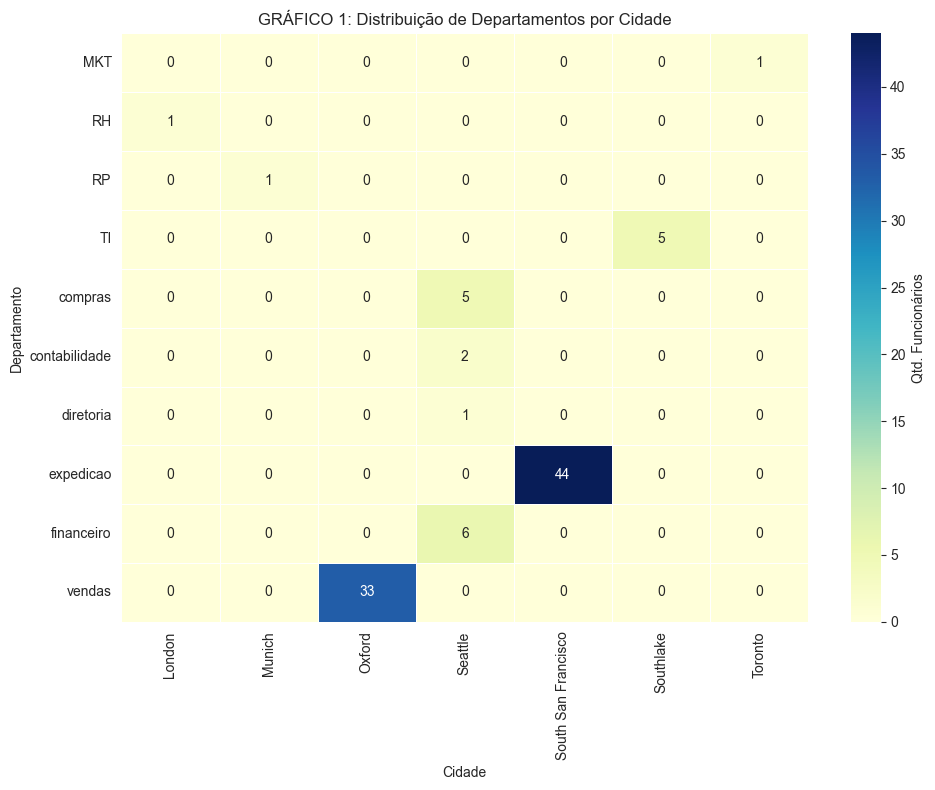

In [17]:
# INICIANDO A ANÁLISE EXPLORATÓRIA DE DADOS (AED) COM BASE NOS DATAFRAMES df_query1 e df_query2 - GERAÇÃO DE GRÁFICOS:

# GRÁFICO 1: Distribuição de Departamentos por Cidade
#df_unido = df_query1.merge(
#    df_query2[['EMPREGADO_ID', 'CIDADE']], 
#    on='EMPREGADO_ID', 
#    how='left'
#)

#df_unido_valido = df_unido[df_unido['CIDADE'] != 'dado_ausente']

pivot = pd.crosstab(df_unido_valido['DEPARTAMENTO'], df_unido_valido['CIDADE'])

plt.figure(figsize=(10, 8))
sns.heatmap(pivot, annot=True, fmt='d', cmap='YlGnBu', linewidths=0.5, cbar_kws={'label': 'Qtd. Funcionários'})
plt.title('GRÁFICO 1: Distribuição de Departamentos por Cidade')
plt.xlabel('Cidade')
plt.ylabel('Departamento')
plt.tight_layout()
plt.show()

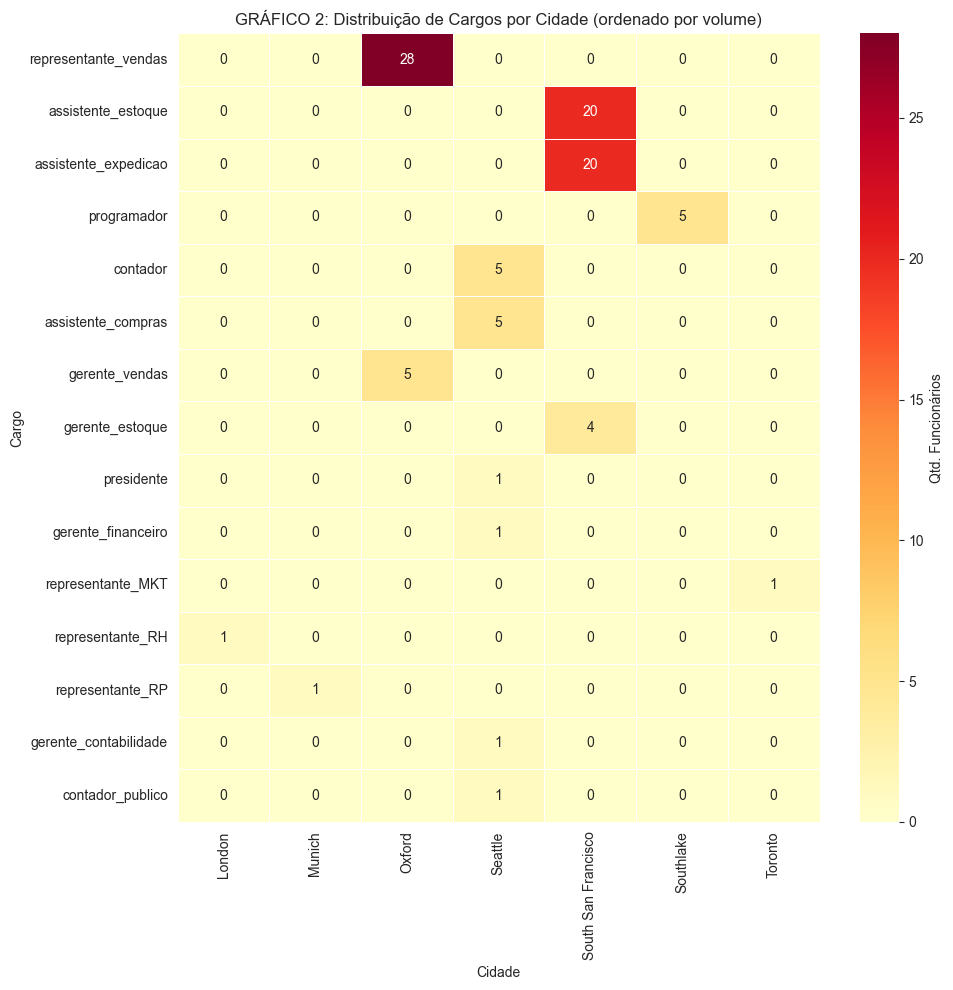

In [18]:
# GRÁFICO 2: Distribuição de Cargos por Cidade

#df_unido = df_query1.merge(
#    df_query2[['EMPREGADO_ID', 'CIDADE']], 
#    on='EMPREGADO_ID', 
#    how='left'
#)

df_unido_valido = df_unido[df_unido['CIDADE'] != 'dado_ausente']

ordem_cargos = df_unido_valido['CARGO'].value_counts().index

pivot_ordenado = pd.crosstab(df_unido_valido['CARGO'], df_unido_valido['CIDADE']).reindex(ordem_cargos)

plt.figure(figsize=(10, 10))
sns.heatmap(pivot_ordenado, annot=True, fmt='d', cmap='YlOrRd', linewidths=0.5, cbar_kws={'label': 'Qtd. Funcionários'})
plt.title('GRÁFICO 2: Distribuição de Cargos por Cidade (ordenado por volume)')
plt.xlabel('Cidade')
plt.ylabel('Cargo')
plt.tight_layout()
plt.show()

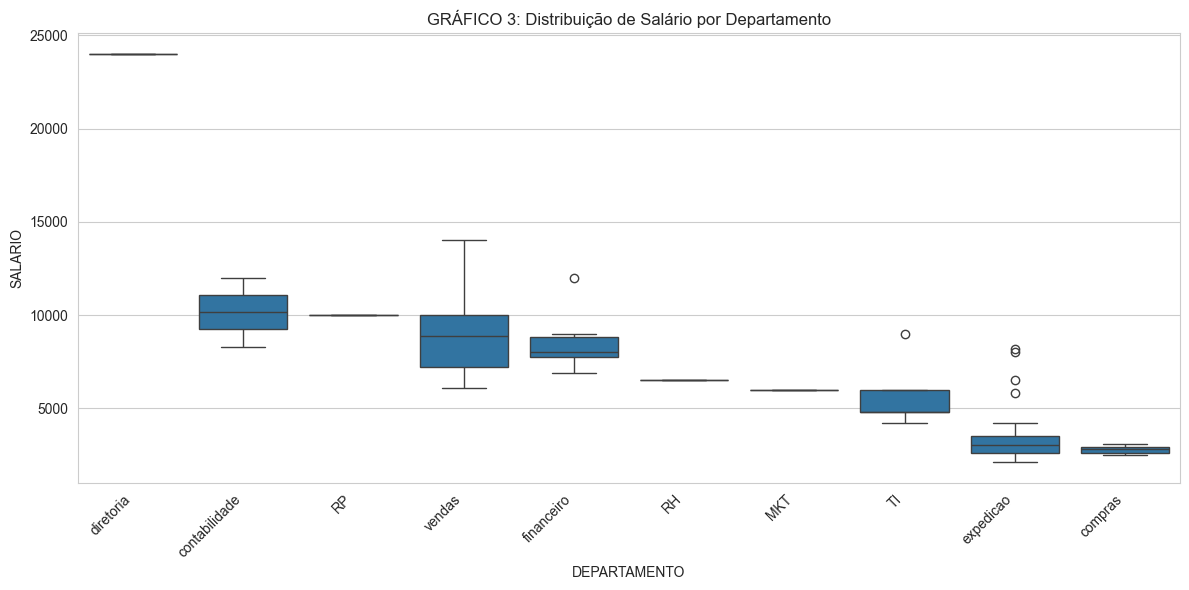

In [19]:
# GRÁFICO 3: Salário x Departamento

plt.figure(figsize=(12, 6))
ordem = df_query1.groupby('DEPARTAMENTO')['SALARIO'].median().sort_values(ascending=False).index
sns.boxplot(data=df_query1, x='DEPARTAMENTO', y='SALARIO', order=ordem)
plt.xticks(rotation=45, ha='right')
plt.title('GRÁFICO 3: Distribuição de Salário por Departamento')
plt.tight_layout()
plt.show()

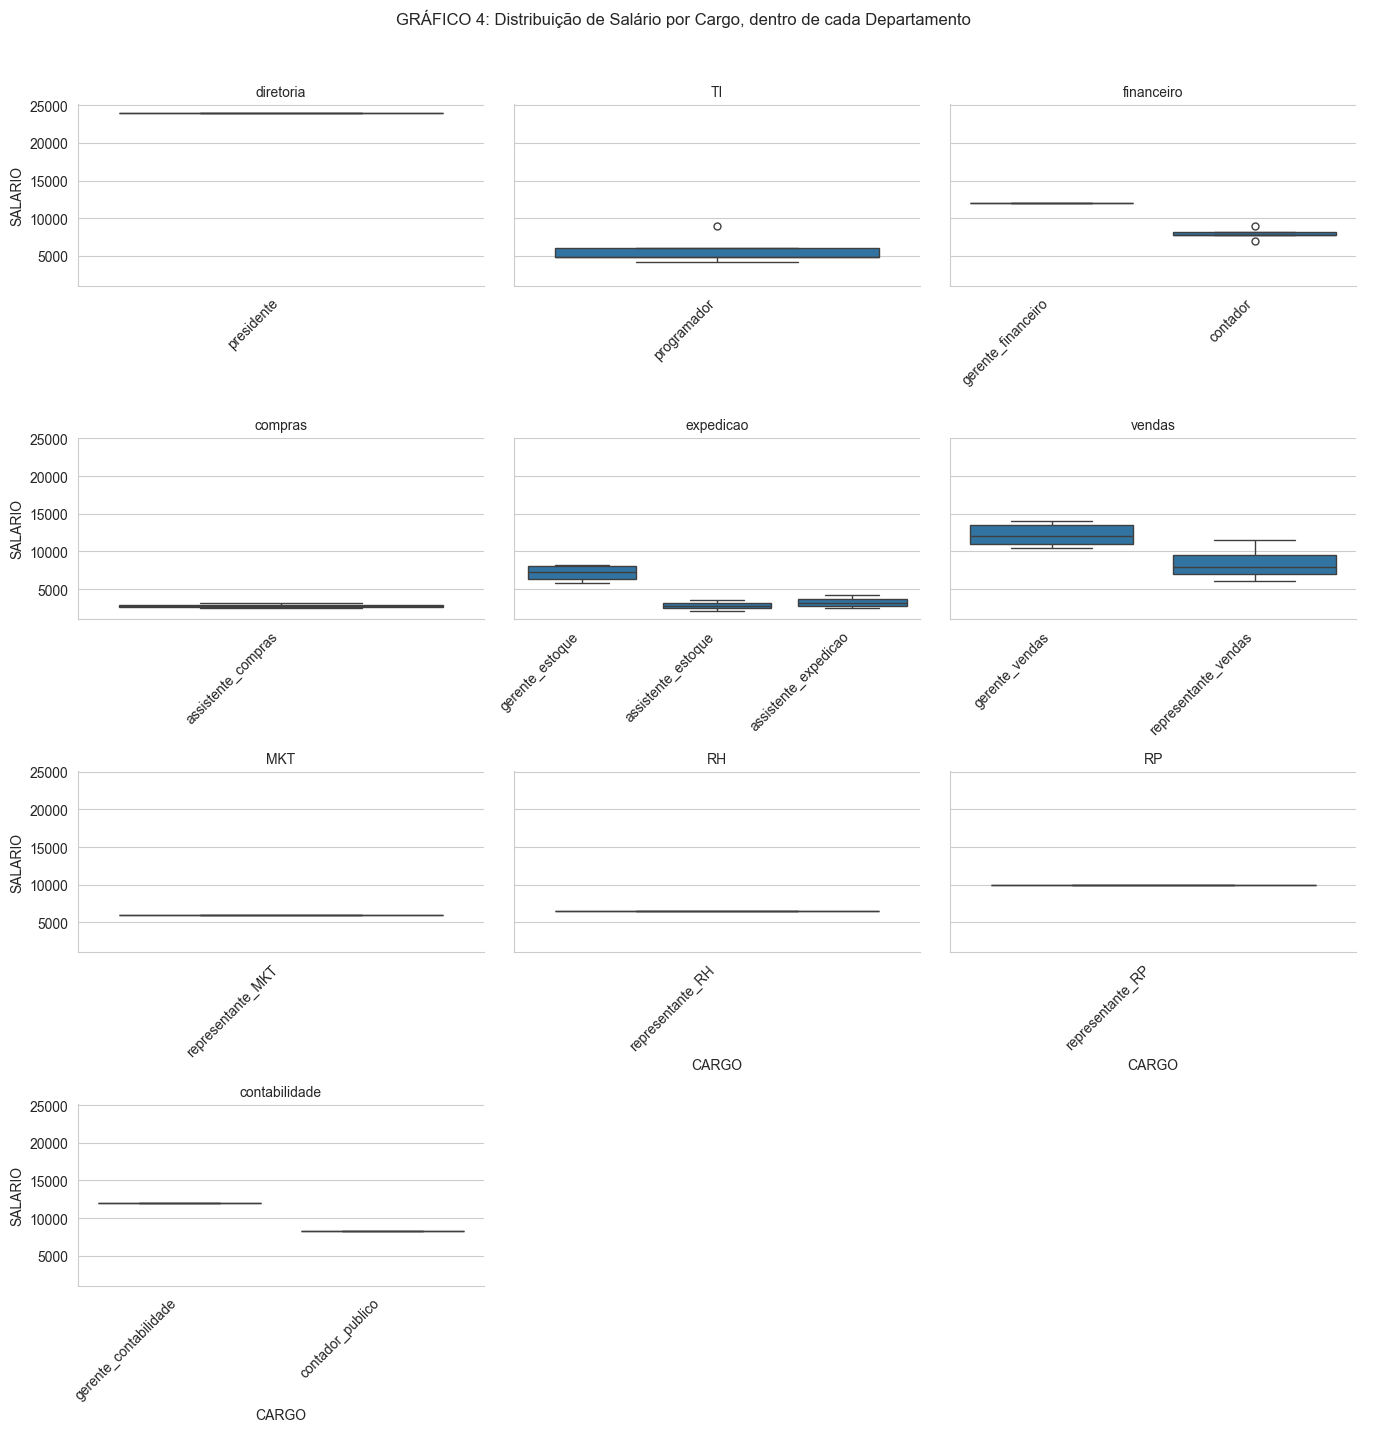

In [20]:
# GRÁFICO 4: Salário x Departamento x Cargo

g = sns.catplot(
    data=df_query1,
    x='CARGO', y='SALARIO',
    col='DEPARTAMENTO',
    kind='box',
    col_wrap=3,          # 3 gráficos por linha
    sharex=False,        # cada painel tem seus próprios cargos no eixo X
    sharey=True,         # mesma escala de salário pra comparar entre departamentos
    height=3.5, aspect=1.3
)

g.set_xticklabels(rotation=45, ha='right')
g.set_titles('{col_name}')
        
g.fig.suptitle('GRÁFICO 4: Distribuição de Salário por Cargo, dentro de cada Departamento', y=1.02)
plt.tight_layout()

plt.show()

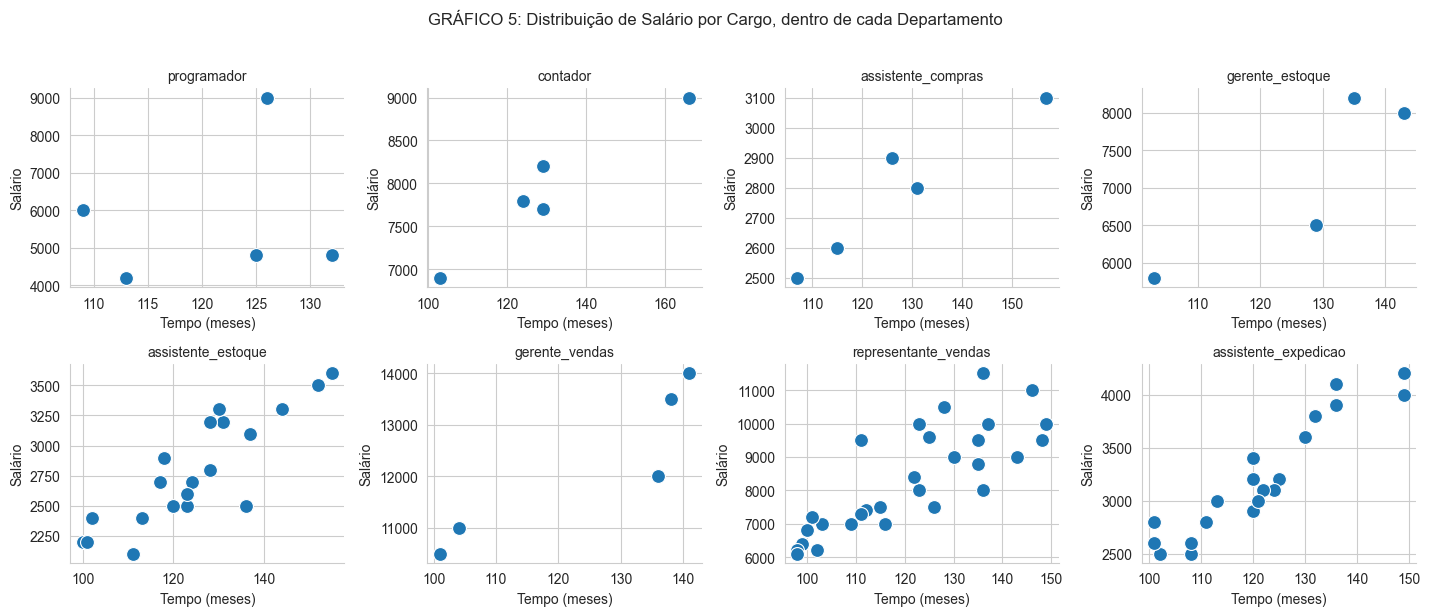

In [26]:
# GRÁFICO 5: Salário x tempo de contratação (Cargos Selecionados)

cargos_excluir = ['presidente', 'gerente_financeiro', 'representante_MKT', 'representante_RH', 
                   'representante_RP', 'gerente_contabilidade', 'contador_publico']

df_filtrado = df_query1[~df_query1['CARGO'].isin(cargos_excluir)]


sns.set_style('whitegrid')

g = sns.relplot(
    data=df_filtrado,
    x='TEMPO_CONTRATACAO_MESES', y='SALARIO',
    col='CARGO',
    col_wrap=4,
    kind='scatter',
    height=3, aspect=1.2,
    s=100,
    facet_kws={'sharey': False, 'sharex': False}
)
g.set_titles('{col_name}')

# força o rótulo do eixo X e Y em TODOS os painéis, não só na última linha
for ax in g.axes.flat:
    if ax.has_data():
        ax.set_xlabel('Tempo (meses)')
        ax.set_ylabel('Salário')
    else:
        ax.set_visible(False)

g.fig.suptitle('GRÁFICO 5: Distribuição de Salário por Cargo, dentro de cada Departamento', y=1.02)
plt.tight_layout()
plt.show()

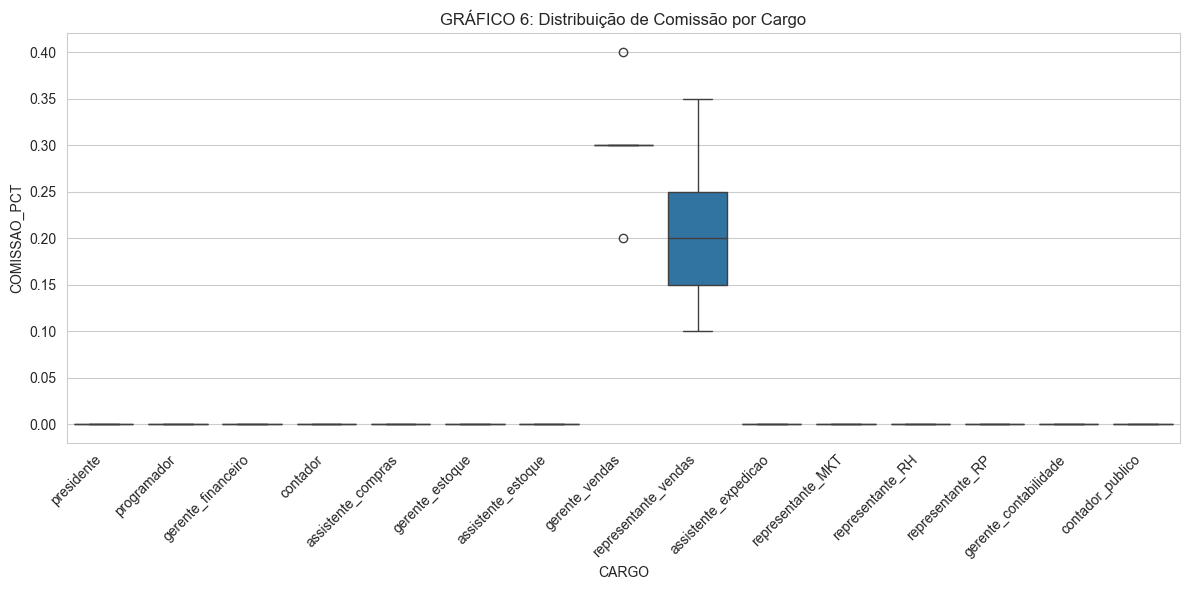

In [22]:
# GRÁFICO 6: Comissão x Cargos

df_comissao = df_query1[df_query1['COMISSAO_PCT'].notna()]

plt.figure(figsize=(12, 6))
sns.boxplot(data=df_comissao, x='CARGO', y='COMISSAO_PCT')
plt.xticks(rotation=45, ha='right')
plt.title('GRÁFICO 6: Distribuição de Comissão por Cargo')
plt.tight_layout()
plt.show()

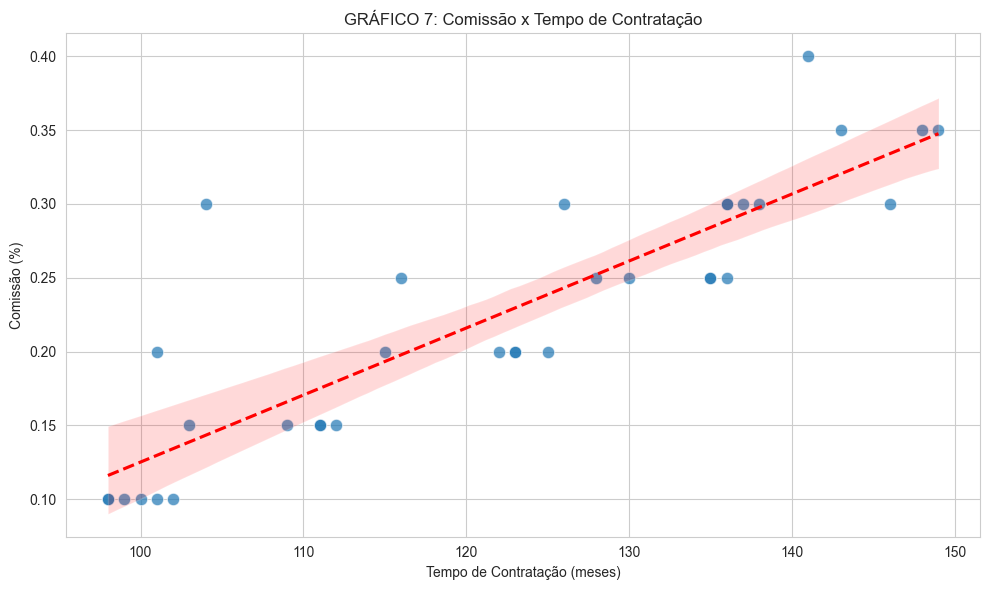

In [23]:
# GRÁFICO 7: Comissão x Tempo de contratação

df_comissao = df_query1[df_query1['COMISSAO_PCT'] > 0]

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_comissao, x='TEMPO_CONTRATACAO_MESES', y='COMISSAO_PCT', s=80, alpha=0.7)
sns.regplot(data=df_comissao, x='TEMPO_CONTRATACAO_MESES', y='COMISSAO_PCT', 
            scatter=False, color='red', line_kws={'linestyle': '--'})
plt.title('GRÁFICO 7: Comissão x Tempo de Contratação')
plt.xlabel('Tempo de Contratação (meses)')
plt.ylabel('Comissão (%)')
plt.tight_layout()
plt.show()

In [24]:
# TABELA 1: Gerente de Vendas - Informações sobre Tempo de Contratação, Comissão e Salário

tabela_gerentes_vendas = df_query1[df_query1['CARGO'] == 'gerente_vendas'][
    ['EMPREGADO_ID', 'CARGO', 'TEMPO_CONTRATACAO_MESES', 'COMISSAO_PCT', 'SALARIO']
].sort_values('TEMPO_CONTRATACAO_MESES', ascending=False)

print(f'\n===== TABELA 1: Gerente de Vendas - Informações sobre Tempo de Contratação, Comissão e Salário =====\n')
print(tabela_gerentes_vendas)


===== TABELA 1: Gerente de Vendas - Informações sobre Tempo de Contratação, Comissão e Salário =====

    EMPREGADO_ID           CARGO  TEMPO_CONTRATACAO_MESES  COMISSAO_PCT  SALARIO
41           145  gerente_vendas                      141         0.40%    14000
42           146  gerente_vendas                      138         0.30%    13500
43           147  gerente_vendas                      136         0.30%    12000
44           148  gerente_vendas                      104         0.30%    11000
45           149  gerente_vendas                      101         0.20%    10500


In [25]:
# TABELA 2: Representante de Vendas - Informações sobre Tempo de Contratação, Comissão e Salário
tabela_representante_vendas = df_query1[df_query1['CARGO'] == 'representante_vendas'][
    ['EMPREGADO_ID', 'CARGO', 'TEMPO_CONTRATACAO_MESES', 'COMISSAO_PCT', 'SALARIO']
].sort_values('TEMPO_CONTRATACAO_MESES', ascending=False)

print(f'\n===== TABELA 2: Representante de Vendas - Informações sobre Tempo de Contratação, Comissão e Salário =====\n')
print(tabela_representante_vendas)


===== TABELA 2: Representante de Vendas - Informações sobre Tempo de Contratação, Comissão e Salário =====

    EMPREGADO_ID                 CARGO  TEMPO_CONTRATACAO_MESES  COMISSAO_PCT  SALARIO
52           156  representante_vendas                      149         0.35%    10000
53           157  representante_vendas                      148         0.35%     9500
70           174  representante_vendas                      146         0.30%    11000
54           158  representante_vendas                      143         0.35%     9000
46           150  representante_vendas                      137         0.30%    10000
64           168  representante_vendas                      136         0.25%    11500
55           159  representante_vendas                      136         0.30%     8000
47           151  representante_vendas                      135         0.25%     9500
71           175  representante_vendas                      135         0.25%     8800
48           152  rep